# Testes não paramétricos

## Testes para k amostras emparelhadas

Estes testes analisam as diferenças entre $k$ (três ou mais) amostras emparelhadas ou relacionadas. A hipótese nula a ser testada é de que $k$ amostras tenham sido extraídas de uma mesma população. 

### Teste de Friedman

O teste de Friedman é aplicado para variáveis quantitativas ou qualitativas em escala ordinal e tem como objetivo verificar se *k* amostras emparelhadas são extraídas da mesma população. É uma extensão do teste de Wilcoxon para três ou mais amostras emparelhadas. É também uma alternativa à Análise de Variância quando suas hipóteses (normalidade dos dados e homogeneidade das variâncias) forem violadas ou quando o tamanho da amostra for pequeno.

A hipótese nula do teste de Friedman assume que as *k* amostras sejam provenientes da mesma população ou de populações com a mesma mediana ($M$). Temos que:

$$
\begin{align}
H_0: M_1 = M_2 = \ldots = M_k \\
H_1: \exists_{i,j}: M_i \neq M_j (i \neq j)
\end{align}
$$

Exemplo: Uma pesquisa é realizada para verificar a eficácia do café da manhã na redução de peso e, para tal, 15 pacientes são acompanhados durantes três meses. São coletados dados referentes ao peso dos pacientes durante três períodos diferentes, conforme mostra a base a seguir: antes do tratamento (AT), pós-tratamento (PT) e depois de três meses de tratamento (D3M). Verifique se o tratamento oferece algum resultado. Considere $\alpha = 5\%$.

In [1]:
import pandas as pd

BASE_CAFE = "../dados/cafe.csv"

df_cafe = pd.read_csv(BASE_CAFE, index_col="Paciente")

df_cafe

,AT,PT,D3M
Paciente,,,
1,65,62,58
2,89,85,80
3,96,95,95
4,90,84,79
5,70,70,66
6,72,65,62
7,87,84,77
8,74,74,69
9,66,64,62


In [2]:
df_cafe.info()    

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 1 to 15
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   AT      15 non-null     int64
 1   PT      15 non-null     int64
 2   D3M     15 non-null     int64
dtypes: int64(3)
memory usage: 492.0 bytes


In [3]:
df_cafe.describe()

,AT,PT,D3M
count,15.000000,15.000000,15.000000
mean,83.266667,80.200000,76.733333
std,17.396497,17.321333,18.312629
min,65.000000,62.000000,58.000000
25%,72.500000,70.000000,66.500000
50%,80.000000,75.000000,71.000000
75%,89.500000,84.500000,79.500000
max,135.000000,132.000000,132.000000


<Axes: ylabel='Count'>

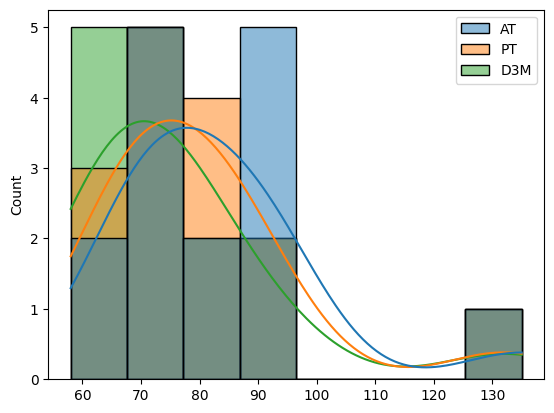

In [4]:
import seaborn as sns 

sns.histplot(df_cafe, kde=True)

<Axes: >

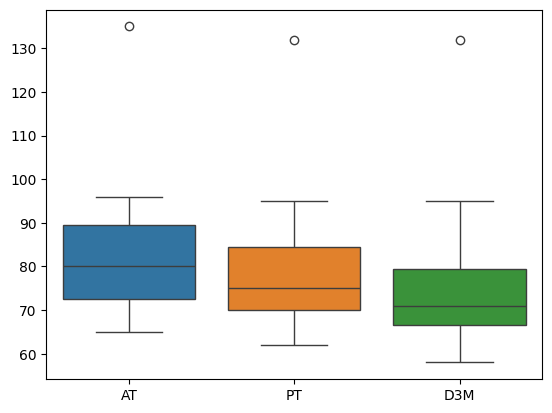

In [5]:
sns.boxplot(df_cafe)

In [6]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_cafe, centro="median")

Teste de Shapiro-Wilk
estatistica_sw=0.819
AT não segue uma distribuição normal (valor p: 0.007)
estatistica_sw=0.814
PT não segue uma distribuição normal (valor p: 0.006)
estatistica_sw=0.790
D3M não segue uma distribuição normal (valor p: 0.003)

Teste de Levene
estatistica_levene=0.002
Variâncias iguais (valor p: 0.998)


In [7]:
from scipy.stats import friedmanchisquare

friedmanchisquare(*[df_cafe[coluna] for coluna in df_cafe.columns])

FriedmanchisquareResult(statistic=np.float64(27.527272727272713), pvalue=np.float64(1.0532432302056965e-06))

Como P < 0,05, rejeitamos a hipótese nula.

In [9]:
from auxiliares import analise_friedman

analise_friedman(df_cafe)

Teste de Friedman
estatistica_friedman=27.527
Rejeita a hipótese nula (valor p: 0.000)
